<a href="https://colab.research.google.com/github/prabishkhadka/7316/blob/main/HighBoostFilter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# High-Boost Filtering (Sharpening)

**Goal:** Enhance edges/details while keeping the original image content.

In this demo:
1) Explain high-boost filtering  
2) Apply it to an image  
3) Show before vs after  
4) Explore different kernels (A values) and compare resultse

## What is High-Boost Filtering?

Images contain:
- **Low-frequency** information → smooth background (slow change)
- **High-frequency** information → edges + fine texture (fast change)

A **high-boost filter** sharpens the image by **adding amplified edge/detail information back** to the original image.


## High-Boost (Unsharp Masking Form)

Let:
- \( f \) = original image  
- \( f_{blur} \) = blurred (low-pass) image  
- \( f - f_{blur} \) = detail (high-frequency component)

Then:
\[
g = f + k(f - f_{blur})
\]

- \( k \) is the **boost factor**
- Higher \( k \) → sharper image, but can amplify noise

## Kernel (3×3) Form

A common high-boost kernel:
\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & 9  & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

A generalized version:
\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & (A+8)  & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

- Increasing **A** increases sharpening strength  
- Too large **A** can cause **halo artifacts** and amplify **noise**

## What should we see?

- Edges become sharper (boundaries pop out)
- Fine textures become more visible
- If A/k is too high → image looks harsh, noisy, or shows bright/dark halos

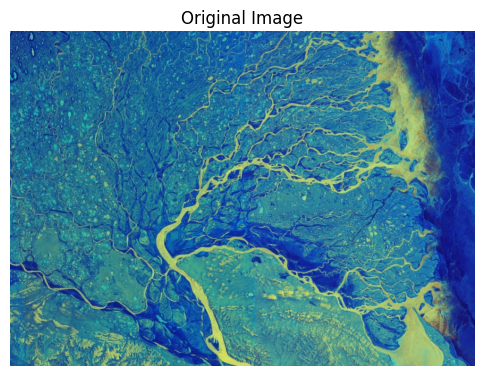

In [5]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

url = "https://media2.spaceref.com/news/2019/esa_earth_from_space_Lena_River_Delta_Russia_062119_945.jpg"

response = requests.get(url)
img = Image.open(BytesIO(response.content))

I = np.array(img)

plt.figure(figsize=(6,6))
plt.imshow(I)
plt.title("Original Image")
plt.axis("off")
plt.show()

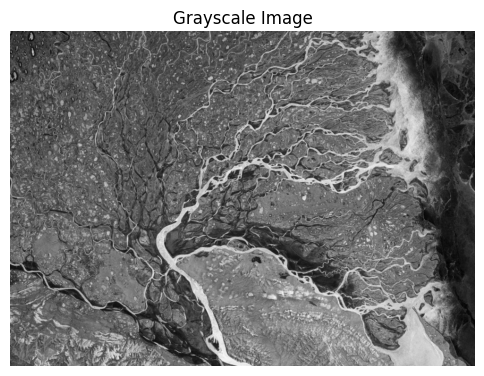

In [6]:
# Convert to grayscale
img_gray = img.convert("L")

# Convert to numpy array
I = np.array(img_gray, dtype=float)

plt.figure(figsize=(6,6))
plt.imshow(I, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [11]:
A = 1

kernel_highboost = np.array([
[-1, -1, -1],
[-1, A+8, -1],
[-1, -1, -1]
])

print("High-Boost Kernel:\n", kernel_highboost)

High-Boost Kernel:
 [[-1 -1 -1]
 [-1  9 -1]
 [-1 -1 -1]]


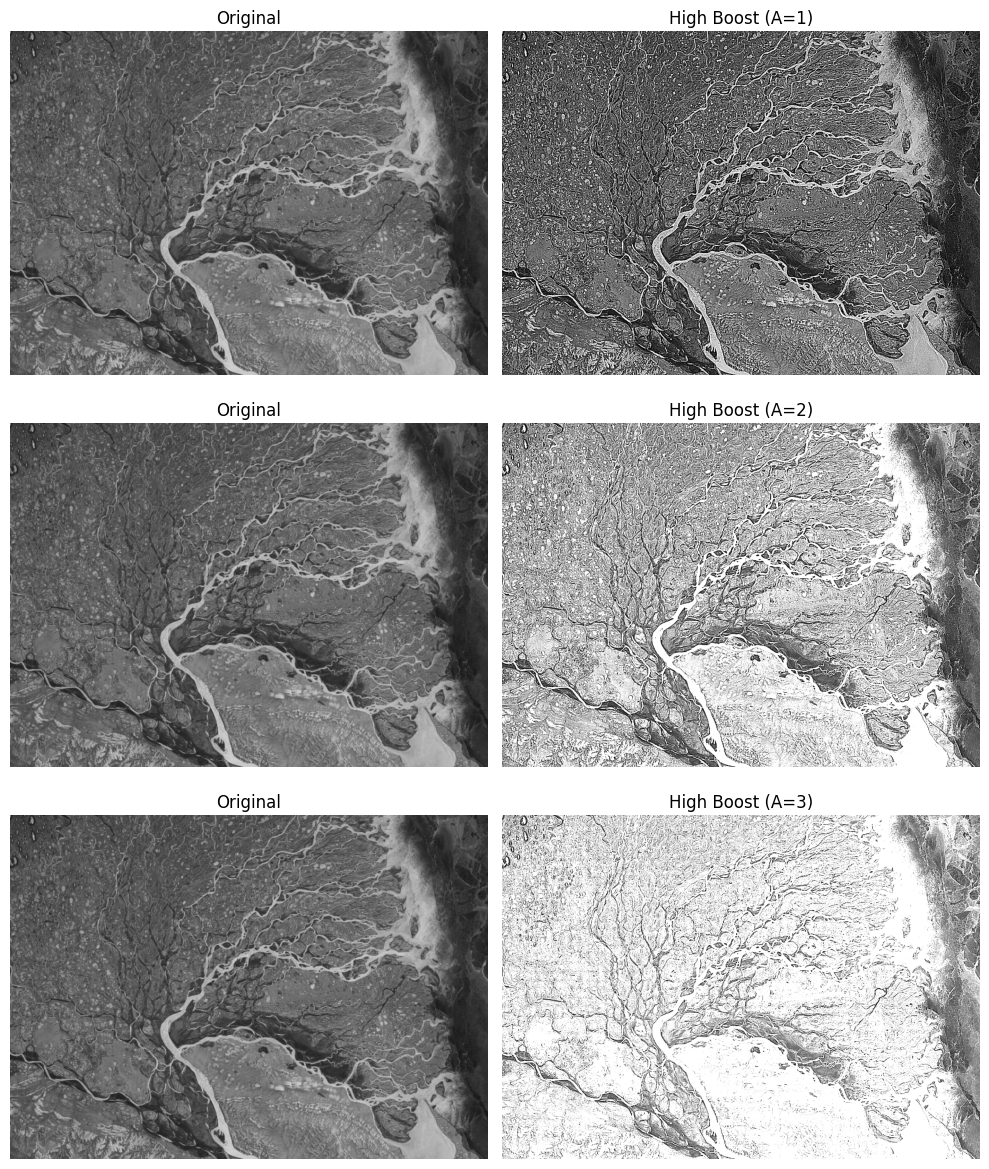

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

A_values = [1,2,3]

plt.figure(figsize=(10,12))

for i, A in enumerate(A_values):

    K = np.array([[-1,-1,-1],

                  [-1,A+8,-1],
                  [-1,-1,-1]], dtype=float)

    hb = convolve2d(I, K, mode='same', boundary='symm')

    # Prevent overflow
    hb = np.clip(hb, 0, 255)

    # Original
    plt.subplot(len(A_values),2,2*i+1)
    plt.imshow(I, cmap='gray', vmin=0, vmax=255)
    plt.title("Original")
    plt.axis('off')

    # High Boost
    plt.subplot(len(A_values),2,2*i+2)
    plt.imshow(hb, cmap='gray', vmin=0, vmax=255)
    plt.title(f"High Boost (A={A})")
    plt.axis('off')

plt.tight_layout()
plt.show()